In [2]:
import pandas as pd
import matplotlib.pyplot as plt

ml = pd.read_csv("../data/nasa_battery/ml_dataset.csv")

print(ml.head())

FileNotFoundError: [Errno 2] No such file or directory: '../data/nasa_battery/ml_dataset.csv'

In [3]:
import os

print(os.getcwd())

c:\Users\nandi\OneDrive\Documents\academics\ev_battery_analytics\notebooks


In [4]:
import os

print(os.listdir())


['battery_degradation_analysis.ipynb']


In [5]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles/Folders Here:")
print(os.listdir())

print("\nOne Level Up:")
print(os.listdir(".."))

Current Folder:
c:\Users\nandi\OneDrive\Documents\academics\ev_battery_analytics\notebooks

Files/Folders Here:
['battery_degradation_analysis.ipynb']

One Level Up:
['dashboard', 'data', 'docs', 'images', 'notebooks', 'README.md', 'sql']


In [6]:
import os

print(os.listdir("../data"))

['kaggle_dataset', 'nasa_dataset']


In [7]:
print(os.listdir("../data/nasa_dataset"))

['data', 'extra_infos', 'metadata.csv', 'ml_dataset.csv']


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

ml = pd.read_csv("../data/nasa_dataset/ml_dataset.csv")

print(ml.head())
print(ml.shape)
print(ml.columns)

  battery_id  ambient_temperature  test_id  Capacity  battery_num
0      B0047                    4        0  1.674305           47
1      B0047                    4        4  1.524366           47
2      B0047                    4        6  1.508076           47
3      B0047                    4        8  1.483558           47
4      B0047                    4       10  1.467139           47
(2769, 5)
Index(['battery_id', 'ambient_temperature', 'test_id', 'Capacity',
       'battery_num'],
      dtype='str')


In [9]:
print(ml["battery_id"].unique())

<ArrowStringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str


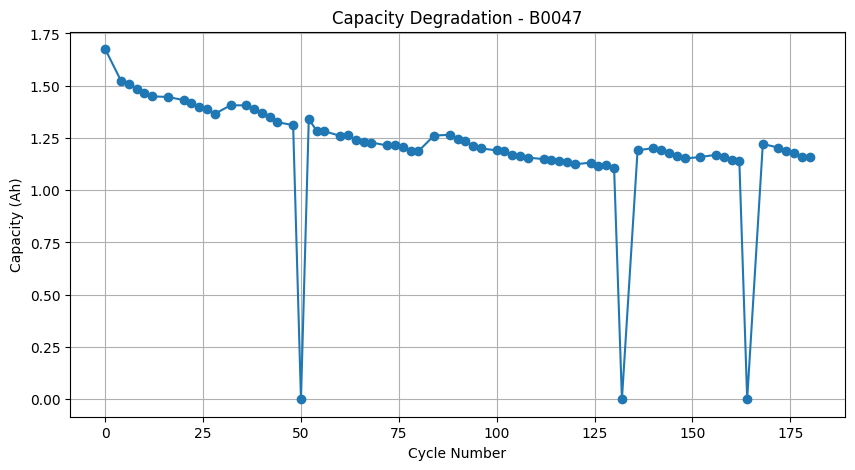

In [10]:
battery = "B0047"

data = ml[ml["battery_id"] == battery]

plt.figure(figsize=(10,5))

plt.plot(
    data["test_id"],
    data["Capacity"],
    marker="o"
)

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title(f"Capacity Degradation - {battery}")

plt.grid(True)

plt.show()

In [12]:
ml_clean = ml[ml["Capacity"] > 0]
print(ml.shape)
print(ml_clean.shape)

(2769, 5)
(2750, 5)


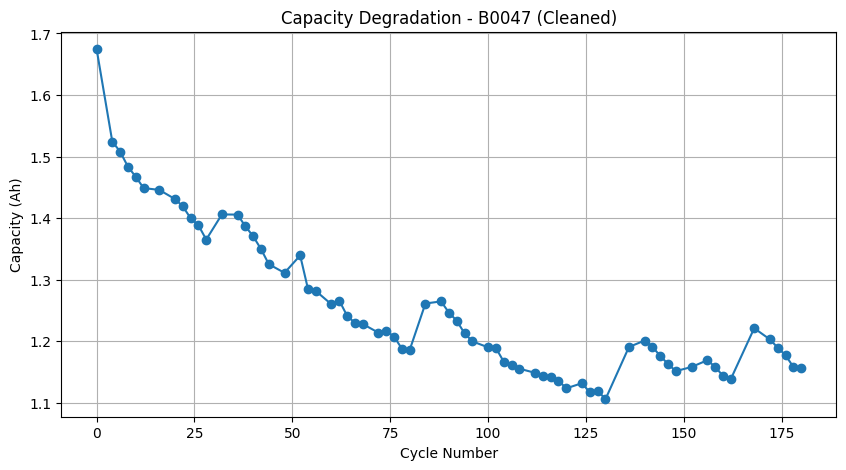

In [13]:
battery = "B0047"

data = ml_clean[ml_clean["battery_id"] == battery]

plt.figure(figsize=(10,5))

plt.plot(
    data["test_id"],
    data["Capacity"],
    marker="o"
)

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title(f"Capacity Degradation - {battery} (Cleaned)")
plt.grid(True)

plt.show()

In [14]:
initial_capacity = data["Capacity"].iloc[0]

data["SOH"] = (
    data["Capacity"] / initial_capacity
) * 100

print(data.head())

  battery_id  ambient_temperature  test_id  Capacity  battery_num         SOH
0      B0047                    4        0  1.674305           47  100.000000
1      B0047                    4        4  1.524366           47   91.044729
2      B0047                    4        6  1.508076           47   90.071793
3      B0047                    4        8  1.483558           47   88.607394
4      B0047                    4       10  1.467139           47   87.626770


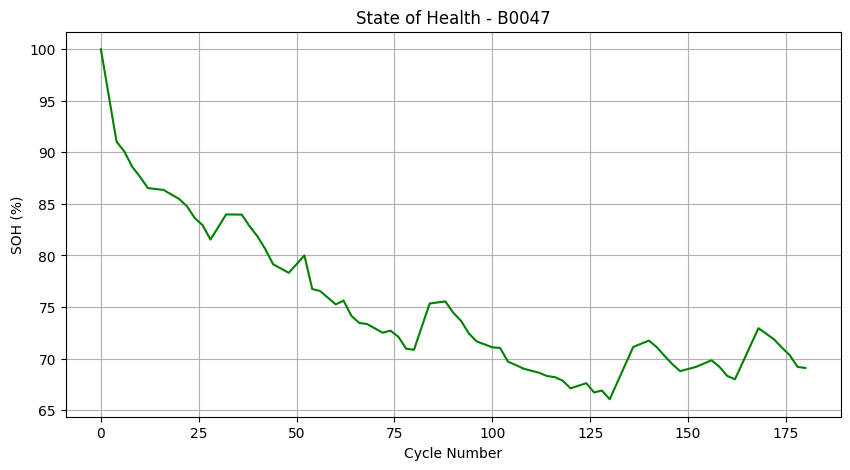

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    data["test_id"],
    data["SOH"],
    color="green"
)

plt.xlabel("Cycle Number")
plt.ylabel("SOH (%)")
plt.title(f"State of Health - {battery}")

plt.grid(True)

plt.show()

In [16]:
battery_summary = []

for battery in ml_clean["battery_id"].unique():

    temp = ml_clean[ml_clean["battery_id"] == battery]

    initial_capacity = temp["Capacity"].iloc[0]
    final_capacity = temp["Capacity"].iloc[-1]

    soh = (final_capacity / initial_capacity) * 100

    battery_summary.append([
        battery,
        initial_capacity,
        final_capacity,
        soh
    ])

summary_df = pd.DataFrame(
    battery_summary,
    columns=[
        "battery_id",
        "initial_capacity",
        "final_capacity",
        "final_soh"
    ]
)

summary_df.head()

,battery_id,initial_capacity,final_capacity,final_soh
0,B0047,1.674305,1.156709,69.085915
1,B0045,1.081979,0.606948,56.096042
2,B0048,1.657996,1.223127,73.771451
3,B0046,1.728239,1.153804,66.761829
4,B0043,1.713783,1.276780,74.500705


In [17]:
summary_df.sort_values(
    "final_soh",
    ascending=False
).head(10)

,battery_id,initial_capacity,final_capacity,final_soh
13,B0033,0.068426,1.315283,1922.204844
15,B0041,0.055620,0.836495,1503.939549
6,B0039,0.119038,1.315339,1104.970767
11,B0034,0.745930,1.280260,171.632680
12,B0038,0.898057,1.530148,170.384165
24,B0052,0.860659,1.351565,157.038327
18,B0036,1.001983,1.559113,155.602798
32,B0056,0.785278,1.129059,143.778234
33,B0055,0.799000,0.990759,123.999928
31,B0054,0.739935,0.837392,113.170992


In [18]:
summary_df.sort_values(
    "final_soh"
).head(10)

,battery_id,initial_capacity,final_capacity,final_soh
23,B0050,0.863145,0.278085,32.217672
1,B0045,1.081979,0.606948,56.096042
26,B0006,2.035338,1.185675,58.254475
3,B0046,1.728239,1.153804,66.761829
0,B0047,1.674305,1.156709,69.085915
27,B0005,1.856487,1.325079,71.375616
29,B0018,1.855005,1.341051,72.293702
2,B0048,1.657996,1.223127,73.771451
17,B0044,1.686526,1.248625,74.035371
4,B0043,1.713783,1.276780,74.500705


In [20]:
temp = ml_clean[
    ml_clean["battery_id"] == battery
].sort_values("test_id")
initial_capacity = temp["Capacity"].iloc[0]
final_capacity = temp["Capacity"].iloc[-1]

In [21]:
#summary table.
battery_summary = []

for battery in ml_clean["battery_id"].unique():

    temp = ml_clean[
        ml_clean["battery_id"] == battery
    ].sort_values("test_id")

    initial_capacity = temp["Capacity"].iloc[0]
    final_capacity = temp["Capacity"].iloc[-1]

    soh = (
        final_capacity / initial_capacity
    ) * 100

    battery_summary.append([
        battery,
        initial_capacity,
        final_capacity,
        soh
    ])

summary_df = pd.DataFrame(
    battery_summary,
    columns=[
        "battery_id",
        "initial_capacity",
        "final_capacity",
        "final_soh"
    ]
) 

In [22]:
summary_df.sort_values(
    "final_soh",
    ascending=False
).head(10)

,battery_id,initial_capacity,final_capacity,final_soh
13,B0033,0.068426,1.315283,1922.204844
15,B0041,0.055620,0.836495,1503.939549
6,B0039,0.119038,1.315339,1104.970767
11,B0034,0.745930,1.280260,171.632680
12,B0038,0.898057,1.530148,170.384165
24,B0052,0.860659,1.351565,157.038327
18,B0036,1.001983,1.559113,155.602798
32,B0056,0.785278,1.129059,143.778234
33,B0055,0.799000,0.990759,123.999928
31,B0054,0.739935,0.837392,113.170992


In [23]:
summary_df.sort_values(
    "final_soh"
).head(10)

,battery_id,initial_capacity,final_capacity,final_soh
23,B0050,0.863145,0.278085,32.217672
1,B0045,1.081979,0.606948,56.096042
26,B0006,2.035338,1.185675,58.254475
3,B0046,1.728239,1.153804,66.761829
0,B0047,1.674305,1.156709,69.085915
27,B0005,1.856487,1.325079,71.375616
29,B0018,1.855005,1.341051,72.293702
2,B0048,1.657996,1.223127,73.771451
17,B0044,1.686526,1.248625,74.035371
4,B0043,1.713783,1.276780,74.500705


In [24]:
summary_df["final_soh"].describe()

count      34.000000
mean      220.650974
std       420.731827
min        32.217672
25%        74.151704
50%        95.060842
75%       121.292694
max      1922.204844
Name: final_soh, dtype: float64

In [5]:
import pandas as pd

ml = pd.read_csv("../data/nasa_dataset/ml_dataset.csv")

ml_clean = ml[ml["Capacity"] > 0]

print(ml_clean.shape)

(2750, 5)


In [6]:
b0033 = ml_clean[
    ml_clean["battery_id"] == "B0033"
].sort_values("test_id")

print(b0033.head(15))

    battery_id  ambient_temperature  test_id  Capacity  battery_num
958      B0033                   24        0  0.068426           33
959      B0033                   24        4  0.689570           33
960      B0033                   24        6  1.161085           33
961      B0033                   24        8  1.252939           33
962      B0033                   24       10  1.302918           33
963      B0033                   24       12  1.321877           33
964      B0033                   24       16  1.288469           33
965      B0033                   24       18  1.713169           33
966      B0033                   24       20  1.656097           33
967      B0033                   24       22  1.619730           33
968      B0033                   24       24  1.604656           33
969      B0033                   24       28  1.625570           33
970      B0033                   24       30  1.590097           33
971      B0033                   24       32  1.

In [7]:
print(b0033["Capacity"].describe())

count    197.000000
mean       1.409510
std        0.283767
min        0.068426
25%        1.359953
50%        1.441282
75%        1.581184
max        1.885140
Name: Capacity, dtype: float64


In [8]:
battery_summary = []

for battery in ml_clean["battery_id"].unique():

    temp = ml_clean[
        ml_clean["battery_id"] == battery
    ].sort_values("test_id")

    initial_capacity = temp["Capacity"].max()
    final_capacity = temp["Capacity"].iloc[-1]

    soh = (final_capacity / initial_capacity) * 100

    battery_summary.append([
        battery,
        initial_capacity,
        final_capacity,
        soh
    ])

summary_df = pd.DataFrame(
    battery_summary,
    columns=[
        "battery_id",
        "initial_capacity",
        "final_capacity",
        "final_soh"
    ]
)

summary_df.sort_values("final_soh").head(10)

,battery_id,initial_capacity,final_capacity,final_soh
23,B0050,2.640149,0.278085,10.532935
22,B0049,2.378644,0.691389,29.066502
25,B0051,2.330873,0.677849,29.081325
7,B0040,1.734130,0.556990,32.119298
1,B0045,1.081979,0.606948,56.096042
26,B0006,2.035338,1.185675,58.254475
18,B0036,2.444062,1.559113,63.791862
3,B0046,1.728239,1.153804,66.761829
15,B0041,1.215649,0.836495,68.810533
0,B0047,1.674305,1.156709,69.085915


In [9]:
summary_df["final_soh"].describe()

count    34.000000
mean     72.173346
std      20.755667
min      10.532935
25%      68.879379
50%      74.141161
75%      87.133820
max      97.370055
Name: final_soh, dtype: float64

In [10]:
summary_df.sort_values(
    "final_soh",
    ascending=False
).head(5)

,battery_id,initial_capacity,final_capacity,final_soh
20,B0026,1.816528,1.768754,97.370055
16,B0027,1.823308,1.770093,97.081395
19,B0025,1.848984,1.767789,95.608686
24,B0052,1.418310,1.351565,95.294061
9,B0028,1.804783,1.717234,95.149016


In [11]:
summary_df.sort_values(
    "final_soh"
).head(5)

,battery_id,initial_capacity,final_capacity,final_soh
23,B0050,2.640149,0.278085,10.532935
22,B0049,2.378644,0.691389,29.066502
25,B0051,2.330873,0.677849,29.081325
7,B0040,1.734130,0.556990,32.119298
1,B0045,1.081979,0.606948,56.096042


In [12]:
battery_temp = []

for battery in ml_clean["battery_id"].unique():

    temp_df = ml_clean[
        ml_clean["battery_id"] == battery
    ]

    temperature = temp_df["ambient_temperature"].iloc[0]

    initial_capacity = temp_df["Capacity"].max()

    final_capacity = temp_df["Capacity"].iloc[-1]

    soh = (
        final_capacity /
        initial_capacity
    ) * 100

    battery_temp.append([
        battery,
        temperature,
        soh
    ])

temp_df = pd.DataFrame(
    battery_temp,
    columns=[
        "battery_id",
        "temperature",
        "soh"
    ]
)

temp_df.groupby(
    "temperature"
)["soh"].mean()

temperature
4     62.836405
22    75.260256
24    75.628341
43    88.110735
Name: soh, dtype: float64

In [13]:
summary_df.sort_values(
    "final_soh",
    ascending=False
).head(5)

,battery_id,initial_capacity,final_capacity,final_soh
20,B0026,1.816528,1.768754,97.370055
16,B0027,1.823308,1.770093,97.081395
19,B0025,1.848984,1.767789,95.608686
24,B0052,1.418310,1.351565,95.294061
9,B0028,1.804783,1.717234,95.149016
